# Romania Football Transfer Data Analysis

## Imports and Setup

In [1]:
import pandas as pd
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


## Load, Merge and Clean Data

In [2]:
# Define the data directory path
data_dir = Path("data")

# Find all CSV files in the data directory
csv_files = list(data_dir.glob("romania_transfers_*.csv"))
csv_files.sort()  # Sort to ensure proper order

# Remove the combined one if it already exists
combined_file = data_dir / "romania_transfers_combined_2003_2024.csv"
if combined_file.exists():
    csv_files.remove(combined_file)
    combined_file.unlink()

print(f"Found {len(csv_files)} CSV files:")
for file in csv_files:
    print(f"  - {file.name}")

Found 22 CSV files:
  - romania_transfers_2003.csv
  - romania_transfers_2004.csv
  - romania_transfers_2005.csv
  - romania_transfers_2006.csv
  - romania_transfers_2007.csv
  - romania_transfers_2008.csv
  - romania_transfers_2009.csv
  - romania_transfers_2010.csv
  - romania_transfers_2011.csv
  - romania_transfers_2012.csv
  - romania_transfers_2013.csv
  - romania_transfers_2014.csv
  - romania_transfers_2015.csv
  - romania_transfers_2016.csv
  - romania_transfers_2017.csv
  - romania_transfers_2018.csv
  - romania_transfers_2019.csv
  - romania_transfers_2020.csv
  - romania_transfers_2021.csv
  - romania_transfers_2022.csv
  - romania_transfers_2023.csv
  - romania_transfers_2024.csv


In [3]:
# Read and combine all CSV files
dataframes = []

print("Reading CSV files...")
for file in csv_files:
    print(f"Reading {file.name}...")
    df = pd.read_csv(file)
    print(f"  - Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    dataframes.append(df)

# Combine all dataframes
print("\nCombining all datasets...")
combined_df = pd.concat(dataframes, ignore_index=True)

print(f"\nCombined dataset shape: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns")
print(f"Years covered: {combined_df['season'].min()} to {combined_df['season'].max()}")

Reading CSV files...
Reading romania_transfers_2003.csv...
  - Shape: 421 rows, 21 columns
Reading romania_transfers_2004.csv...
  - Shape: 437 rows, 21 columns
Reading romania_transfers_2005.csv...
  - Shape: 466 rows, 21 columns
Reading romania_transfers_2006.csv...
  - Shape: 740 rows, 21 columns
Reading romania_transfers_2007.csv...
  - Shape: 746 rows, 21 columns
Reading romania_transfers_2008.csv...
  - Shape: 846 rows, 21 columns
Reading romania_transfers_2009.csv...
  - Shape: 762 rows, 21 columns
Reading romania_transfers_2010.csv...
  - Shape: 977 rows, 21 columns
Reading romania_transfers_2011.csv...
  - Shape: 802 rows, 21 columns
Reading romania_transfers_2012.csv...
  - Shape: 993 rows, 21 columns
Reading romania_transfers_2013.csv...
  - Shape: 850 rows, 21 columns
Reading romania_transfers_2014.csv...
  - Shape: 960 rows, 21 columns
Reading romania_transfers_2015.csv...
  - Shape: 778 rows, 21 columns
Reading romania_transfers_2016.csv...
  - Shape: 725 rows, 21 columns

In [4]:
# Examine the combined dataset
print("Dataset Info:")
print("=" * 50)
print(f"Total records: {len(combined_df):,}")
print(f"Columns: {list(combined_df.columns)}")
print(f"\nData types:")
print(combined_df.dtypes)

print(f"\nSample of the combined dataset:")
print(combined_df.head())

Dataset Info:
Total records: 17,409
Columns: ['team_name', 'league', 'country', 'season', 'transfer_type', 'player_name', 'player_url', 'player_position', 'player_age', 'player_nationality', 'club_2', 'league_2', 'country_2', 'transfer_fee', 'is_loan', 'transfer_notes', 'window', 'in_squad', 'appearances', 'goals', 'minutes_played']

Data types:
team_name              object
league                 object
country                object
season                  int64
transfer_type          object
player_name            object
player_url             object
player_position        object
player_age             object
player_nationality     object
club_2                 object
league_2               object
country_2              object
transfer_fee          float64
is_loan                  bool
transfer_notes         object
window                 object
in_squad              float64
appearances           float64
goals                 float64
minutes_played        float64
dtype: object

Sample 

In [5]:
# Save the combined dataset to a new CSV file
output_file = data_dir / "romania_transfers_combined_2003_2024.csv"

print(f"Saving combined dataset to: {output_file}")
combined_df.to_csv(output_file, index=False, mode='w')

print(f"\nSuccessfully saved combined dataset!")
print(f"File location: {output_file.absolute()}")
print(f"Total records: {len(combined_df):,}")
print(f"Years covered: {combined_df['season'].min()}-{combined_df['season'].max()}")

# Verify the file was created
if output_file.exists():
    file_size = output_file.stat().st_size / (1024 * 1024)  # Size in MB
    print(f"File size: {file_size:.2f} MB")
else:
    print("Error: File was not created!")


Saving combined dataset to: data\romania_transfers_combined_2003_2024.csv

Successfully saved combined dataset!
File location: d:\Data Analysis, Job-uri si Programare\Transfer Analysis Superliga\data\romania_transfers_combined_2003_2024.csv
Total records: 17,409
Years covered: 2003-2024
File size: 3.58 MB


In [6]:
# Load the combined dataset
df = pd.read_csv('data/romania_transfers_combined_2003_2024.csv')

## Viz 1: Percentage of Money Spent in the league for each position between 2003 and 2024

In [7]:
# Filter for permanent arrivals with a transfer fee
# We are only interested in actual purchases, not loans or free transfers.
df_arrivals = df[
    (df['transfer_type'] == 'Arrivals') &
    (df['is_loan'] == False) &
    (df['transfer_fee'] > 0)
].copy()

In [8]:
# Convert season to integer for easier plotting
df_arrivals['season'] = df_arrivals['season'].astype(int)

In [9]:
# Position Grouping
# The dataset uses specific position names. We need to map them to broader categories
# similar to the Premier League analysis to make a valid comparison.
def map_position_group(position):
    """Maps detailed player positions to broader categories."""
    if pd.isna(position):
        return 'Unknown'
    if position == 'Goalkeeper':
        return 'Goalkeeper'
    if 'Centre-Back' in position:
        return 'Centre-back'
    if 'Left-Back' in position or 'Right-Back' in position:
        return 'Full-back'
    if 'Centre-Forward' in position or 'Second Striker' in position:
        return 'Centre-forward'
    if 'Attacking Midfield' in position or 'Winger' in position:
        return 'Attacking midfielders/wide players'
    if 'Defensive Midfield' in position or 'Central Midfield' in position or 'Left Midfield' in position or 'Right Midfield' in position:
        return 'Midfielder'
    return 'Unknown' # Catch any other positions

In [10]:
# Apply the mapping function to create a new 'position_group' column
df_arrivals['position_group'] = df_arrivals['player_position'].apply(map_position_group)

In [11]:
# Data Aggregation and Percentage Calculation
# Calculate the total transfer spend for each season
total_spend_per_season = df_arrivals.groupby('season')['transfer_fee'].sum().reset_index()
total_spend_per_season.rename(columns={'transfer_fee': 'total_seasonal_spend'}, inplace=True)

In [12]:
# Calculate the spend for each position group within each season
spend_by_position_season = df_arrivals.groupby(['season', 'position_group'])['transfer_fee'].sum().reset_index()

In [13]:
# Merge the two dataframes to calculate the percentage
merged_df = pd.merge(spend_by_position_season, total_spend_per_season, on='season')

In [14]:
# Calculate the percentage of total spend for each position group
merged_df['percentage_spend'] = (merged_df['transfer_fee'] / merged_df['total_seasonal_spend']) * 100

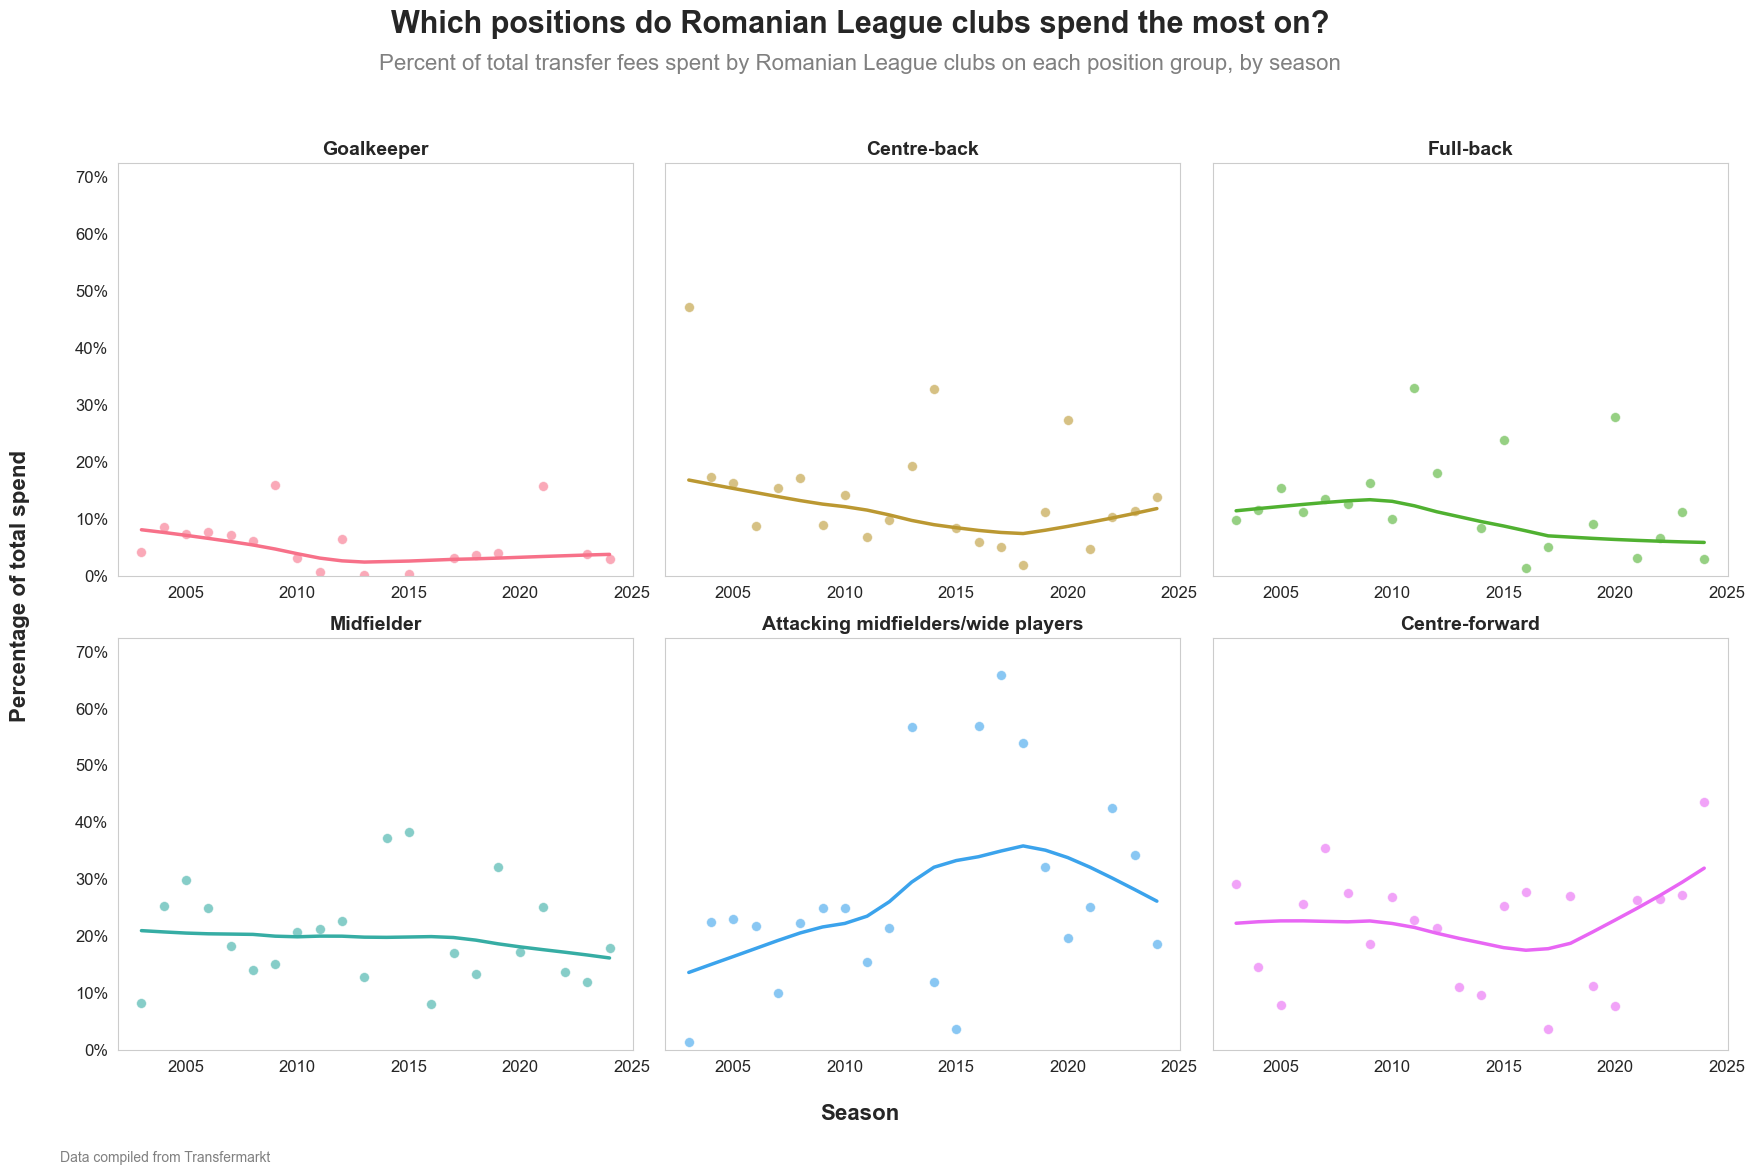

In [15]:
# Visualization
# Set up the plot style to be similar to the inspiration image
sns.set_style("whitegrid", {'axes.grid': False})
plt.rc('font', family='sans-serif')

# Define the order and colors for the plots
position_groups = [
    'Goalkeeper', 'Centre-back', 'Full-back',
    'Midfielder', 'Attacking midfielders/wide players', 'Centre-forward'
]

# Using a color palette that is visually appealing and distinct
colors = sns.color_palette("husl", 6)
color_map = dict(zip(position_groups, colors))

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Set the main title and subtitle
fig.suptitle(
    "Which positions do Romanian League clubs spend the most on?",
    fontsize=22,
    fontweight='bold',
    ha='center',
    y=0.98
)
fig.text(
    0.5, 0.93,
    "Percent of total transfer fees spent by Romanian League clubs on each position group, by season",
    fontsize=16,
    ha='center',
    color='gray'
)

# Generate a plot for each position group
for i, pos_group in enumerate(position_groups):
    ax = axes[i]
    group_data = merged_df[merged_df['position_group'] == pos_group]

    if not group_data.empty:
        # Create a scatter plot for the data points
        sns.scatterplot(
            x='season',
            y='percentage_spend',
            data=group_data,
            ax=ax,
            color=color_map[pos_group],
            alpha=0.6,
            s=50, # size of points
            legend=False
        )
        # Add a smoothed trend line using LOWESS (Locally Weighted Scatterplot Smoothing)
        sns.regplot(
            x='season',
            y='percentage_spend',
            data=group_data,
            ax=ax,
            scatter=False,
            lowess=True,
            color=color_map[pos_group],
            line_kws={'linewidth': 2.5}
        )

    # Set subplot titles and labels
    ax.set_title(pos_group, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Set y-axis limits and format as percentage
    ax.set_ylim(0, max(60, merged_df['percentage_spend'].max() * 1.1))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

    # Customize ticks
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Set x-axis ticks to be integers representing the year
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
    plt.setp(ax.get_xticklabels(), rotation=0)


# Add common axis labels
fig.text(0.5, 0.06, 'Season', ha='center', va='center', fontsize=16, fontweight='bold')
fig.text(0.08, 0.5, 'Percentage of total spend', ha='center', va='center', rotation='vertical', fontsize=16, fontweight='bold')

# Add data source note
fig.text(0.1, 0.02, 'Data compiled from Transfermarkt', fontsize=10, color='gray')

# Adjust layout and display the plot
plt.tight_layout(rect=[0.1, 0.08, 0.95, 0.92]) # Adjust rect to make space for titles
plt.show()

## Some additional comprehensive analysis for the period 2003-2024

In [16]:
# Create a comprehensive season analysis dataframe
season_analysis_list = []

# Get all unique seasons
all_seasons = sorted(df_arrivals['season'].unique())

for season in all_seasons:
    print(f"Processing season {season}...")
    
    # Filter data for this season
    season_arrivals = df_arrivals[df_arrivals['season'] == season]
    
    # Get total spending for this season
    season_total_spend = total_spend_per_season[total_spend_per_season['season'] == season]['total_seasonal_spend'].iloc[0]
    
    # Get spending by position for this season
    season_spend = spend_by_position_season[spend_by_position_season['season'] == season]
    
    # Get percentages for this season
    season_percentages = merged_df[merged_df['season'] == season]
    
    # Count transfers by position
    transfer_counts = season_arrivals.groupby('position_group').size().reset_index(name='transfer_count')
    
    # Calculate average transfer fee by position
    avg_fees = season_arrivals.groupby('position_group')['transfer_fee'].mean().reset_index()
    avg_fees.rename(columns={'transfer_fee': 'avg_transfer_fee'}, inplace=True)
    
    # Calculate median transfer fee by position
    median_fees = season_arrivals.groupby('position_group')['transfer_fee'].median().reset_index()
    median_fees.rename(columns={'transfer_fee': 'median_transfer_fee'}, inplace=True)
    
    # Create season summary
    for _, pos_row in season_percentages.iterrows():
        position = pos_row['position_group']
        
        # Get additional stats for this position
        pos_transfers = transfer_counts[transfer_counts['position_group'] == position]
        pos_avg = avg_fees[avg_fees['position_group'] == position]
        pos_median = median_fees[median_fees['position_group'] == position]
        
        season_analysis_list.append({
            'season': season,
            'position_group': position,
            'total_spend': pos_row['transfer_fee'],
            'total_seasonal_spend': season_total_spend,
            'percentage_spend': pos_row['percentage_spend'],
            'transfer_count': pos_transfers['transfer_count'].iloc[0] if not pos_transfers.empty else 0,
            'avg_transfer_fee': pos_avg['avg_transfer_fee'].iloc[0] if not pos_avg.empty else 0,
            'median_transfer_fee': pos_median['median_transfer_fee'].iloc[0] if not pos_median.empty else 0
        })

# Create the comprehensive dataframe
season_analysis_df = pd.DataFrame(season_analysis_list)

# Add some additional calculated columns
season_analysis_df['avg_percentage_of_total'] = (season_analysis_df['avg_transfer_fee'] / season_analysis_df['total_seasonal_spend']) * 100

# Round numerical columns for better readability
season_analysis_df['percentage_spend'] = season_analysis_df['percentage_spend'].round(2)
season_analysis_df['avg_transfer_fee'] = season_analysis_df['avg_transfer_fee'].round(0)
season_analysis_df['median_transfer_fee'] = season_analysis_df['median_transfer_fee'].round(0)
season_analysis_df['avg_percentage_of_total'] = season_analysis_df['avg_percentage_of_total'].round(4)

# Sort by season and position group
season_analysis_df = season_analysis_df.sort_values(['season', 'position_group']).reset_index(drop=True)

# Save to CSV
output_path = data_dir / "romania_transfer_analysis_by_season_position.csv"
season_analysis_df.to_csv(output_path, index=False)

print(f"\n=== ANALYSIS COMPLETE ===")
print(f"Saved comprehensive analysis to: {output_path}")
print(f"Total records: {len(season_analysis_df)}")
print(f"Seasons covered: {season_analysis_df['season'].min()}-{season_analysis_df['season'].max()}")
print(f"Position groups: {sorted(season_analysis_df['position_group'].unique())}")

# Display sample of the data
print(f"\nSample of the analysis data:")
print(season_analysis_df.head(10))

# Show summary statistics
print(f"\nSummary by position group (average across all seasons):")
summary_stats = season_analysis_df.groupby('position_group').agg({
    'percentage_spend': 'mean',
    'transfer_count': 'mean',
    'avg_transfer_fee': 'mean',
    'total_spend': 'mean'
}).round(2)
print(summary_stats)

Processing season 2003...
Processing season 2004...
Processing season 2005...
Processing season 2006...
Processing season 2007...
Processing season 2008...
Processing season 2009...
Processing season 2010...
Processing season 2011...
Processing season 2012...
Processing season 2013...
Processing season 2014...
Processing season 2015...
Processing season 2016...
Processing season 2017...
Processing season 2018...
Processing season 2019...
Processing season 2020...
Processing season 2021...
Processing season 2022...
Processing season 2023...
Processing season 2024...

=== ANALYSIS COMPLETE ===
Saved comprehensive analysis to: data\romania_transfer_analysis_by_season_position.csv
Total records: 127
Seasons covered: 2003-2024
Position groups: ['Attacking midfielders/wide players', 'Centre-back', 'Centre-forward', 'Full-back', 'Goalkeeper', 'Midfielder', 'Unknown']

Sample of the analysis data:
   season                      position_group  total_spend  \
0    2003  Attacking midfielders/wi

## Viz 2: Number of Free Agent Signings by Position

In [17]:
# --- Data Cleaning and Feature Engineering ---
# We are only interested in permanent arrivals (not loans)
df_permanent_arrivals = df[
    (df['transfer_type'] == 'Arrivals') &
    (df['is_loan'] == False)
].copy()

In [18]:
# Convert season to integer
df_permanent_arrivals['season'] = df_permanent_arrivals['season'].astype(int)

In [19]:
# Apply the position mapping
df_permanent_arrivals['position_group'] = df_permanent_arrivals['player_position'].apply(map_position_group)

In [20]:
# Create a column to distinguish transfer type
df_permanent_arrivals['transfer_category'] = np.where(df_permanent_arrivals['transfer_fee'] > 0, 'Paid Transfer', 'Free Transfer')

In [21]:
print("\nData prepared for analysis.")
print(f"Total permanent arrivals found: {len(df_permanent_arrivals)}")
print(f"Transfer categories:\n{df_permanent_arrivals['transfer_category'].value_counts()}")


Data prepared for analysis.
Total permanent arrivals found: 6303
Transfer categories:
transfer_category
Free Transfer    5443
Paid Transfer     860
Name: count, dtype: int64


In [22]:
# Filter for free transfers only
df_free_agents = df_permanent_arrivals[df_permanent_arrivals['transfer_category'] == 'Free Transfer'].copy()

In [23]:
# Calculate the number of free agents for each position group within each season
free_agent_counts = df_free_agents.groupby(['season', 'position_group']).size().reset_index(name='player_count')

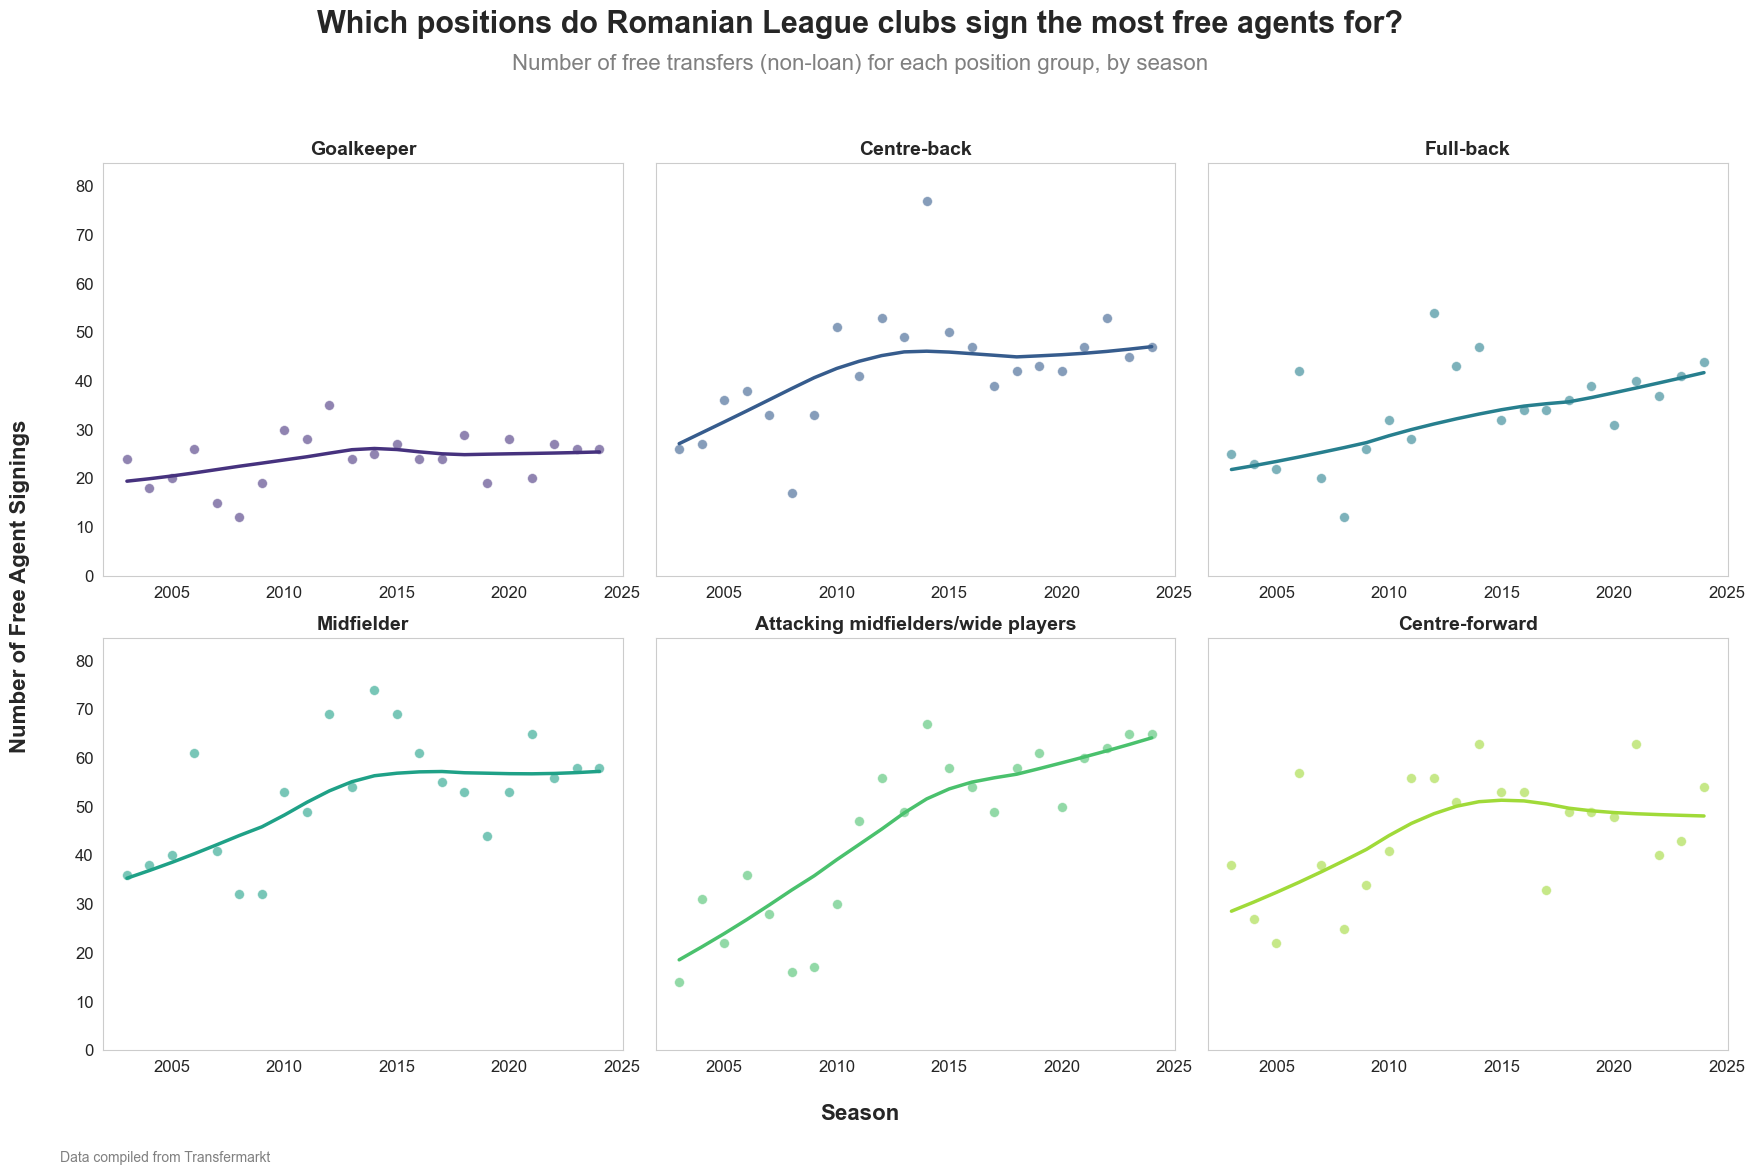

In [24]:
# --- Visualization ---
sns.set_style("whitegrid", {'axes.grid': False})
plt.rc('font', family='sans-serif')

position_groups = [
    'Goalkeeper', 'Centre-back', 'Full-back',
    'Midfielder', 'Attacking midfielders/wide players', 'Centre-forward'
]
colors = sns.color_palette("viridis", 6)
color_map = dict(zip(position_groups, colors))

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)
axes = axes.flatten()

fig.suptitle(
    "Which positions do Romanian League clubs sign the most free agents for?",
    fontsize=22, fontweight='bold', ha='center', y=0.98
)
fig.text(
    0.5, 0.93,
    "Number of free transfers (non-loan) for each position group, by season",
    fontsize=16, ha='center', color='gray'
)

for i, pos_group in enumerate(position_groups):
    ax = axes[i]
    group_data = free_agent_counts[free_agent_counts['position_group'] == pos_group]

    if not group_data.empty:
        # Scatter plot for data points
        sns.scatterplot(
            x='season', y='player_count', data=group_data, ax=ax,
            color=color_map[pos_group], alpha=0.6, s=50, legend=False
        )
        # Smoothed trend line
        sns.regplot(
            x='season', y='player_count', data=group_data, ax=ax,
            scatter=False, lowess=True, color=color_map[pos_group], line_kws={'linewidth': 2.5}
        )

    ax.set_title(pos_group, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(0, max(60, free_agent_counts['player_count'].max() * 1.1))
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
    plt.setp(ax.get_xticklabels(), rotation=0)

fig.text(0.5, 0.06, 'Season', ha='center', va='center', fontsize=16, fontweight='bold')
fig.text(0.08, 0.5, 'Number of Free Agent Signings', ha='center', va='center', rotation='vertical', fontsize=16, fontweight='bold')
fig.text(0.1, 0.02, 'Data compiled from Transfermarkt', fontsize=10, color='gray')

plt.tight_layout(rect=[0.1, 0.08, 0.95, 0.92])
plt.show()

## Viz 3: Free vs Paid Transfers Over Time

In [25]:
# Count transfers by season and category
transfer_comparison = df_permanent_arrivals.groupby(['season', 'transfer_category']).size().unstack(fill_value=0)

In [26]:
# Ensure both columns exist, even if a season had 0 of one type
if 'Paid Transfer' not in transfer_comparison:
    transfer_comparison['Paid Transfer'] = 0
if 'Free Transfer' not in transfer_comparison:
    transfer_comparison['Free Transfer'] = 0

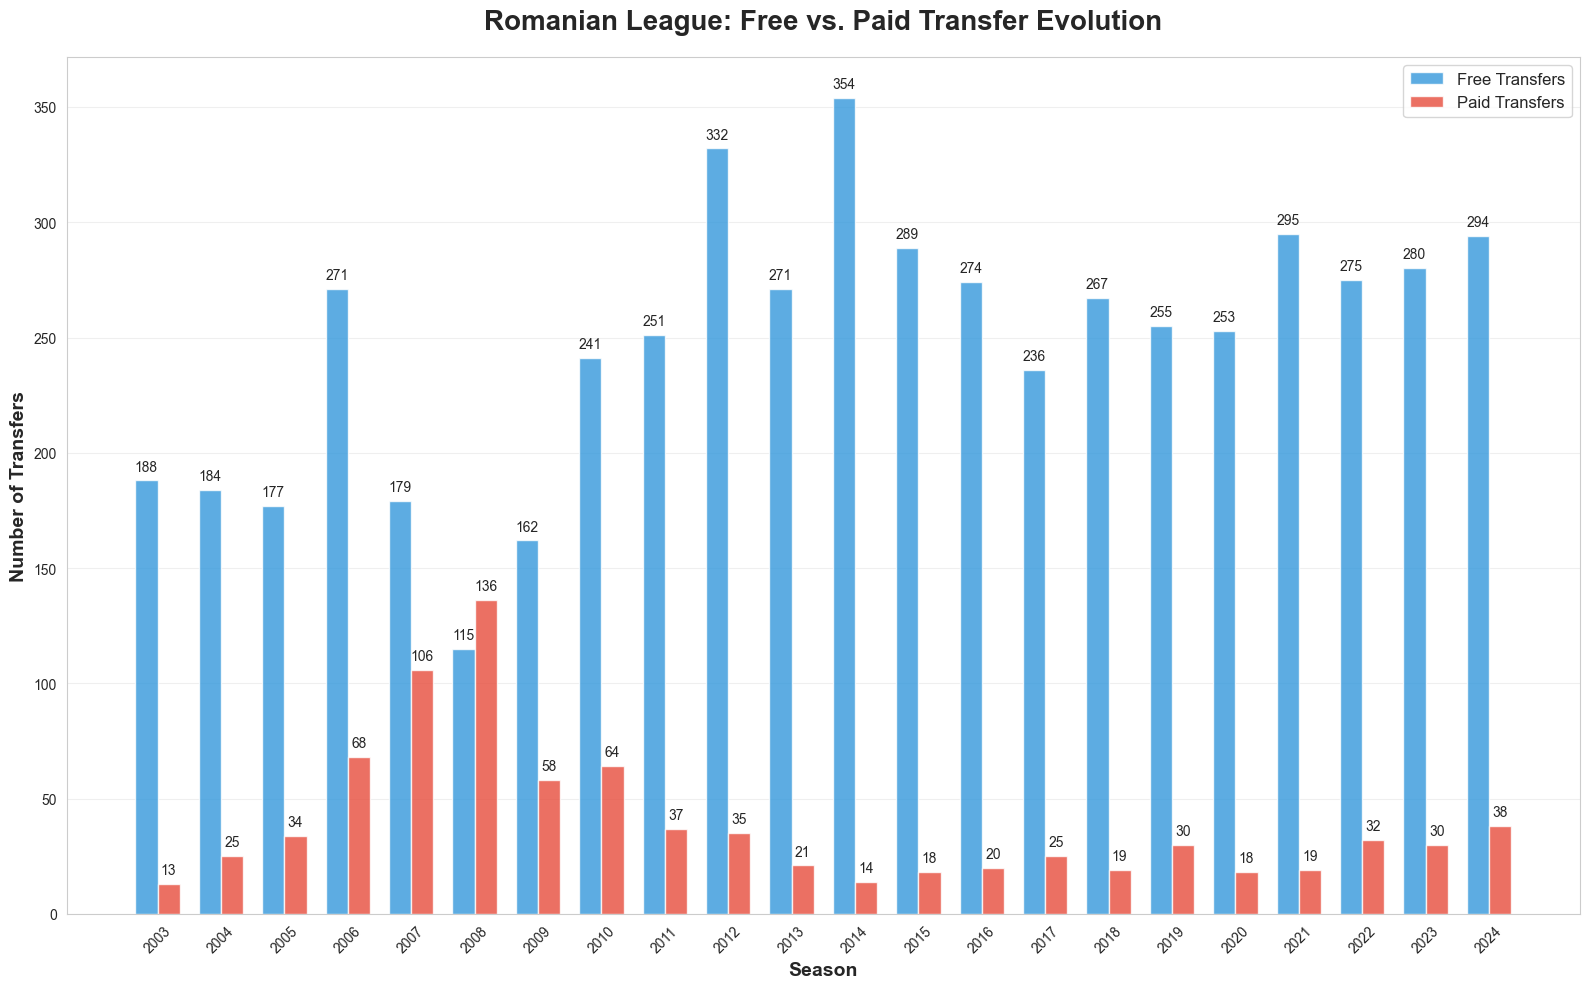

In [27]:
# Side-by-side bar chart with modern styling
fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(transfer_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, transfer_comparison['Free Transfer'], width, 
               label='Free Transfers', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, transfer_comparison['Paid Transfer'], width,
               label='Paid Transfers', color='#e74c3c', alpha=0.8)

# Modern styling
ax.set_title('Romanian League: Free vs. Paid Transfer Evolution', 
             fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Transfers', fontsize=14, fontweight='bold')

# Set x-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(transfer_comparison.index, rotation=45)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Viz 4: Player Origins by Region Over Time

Nations still attributed to 'Other' region: None


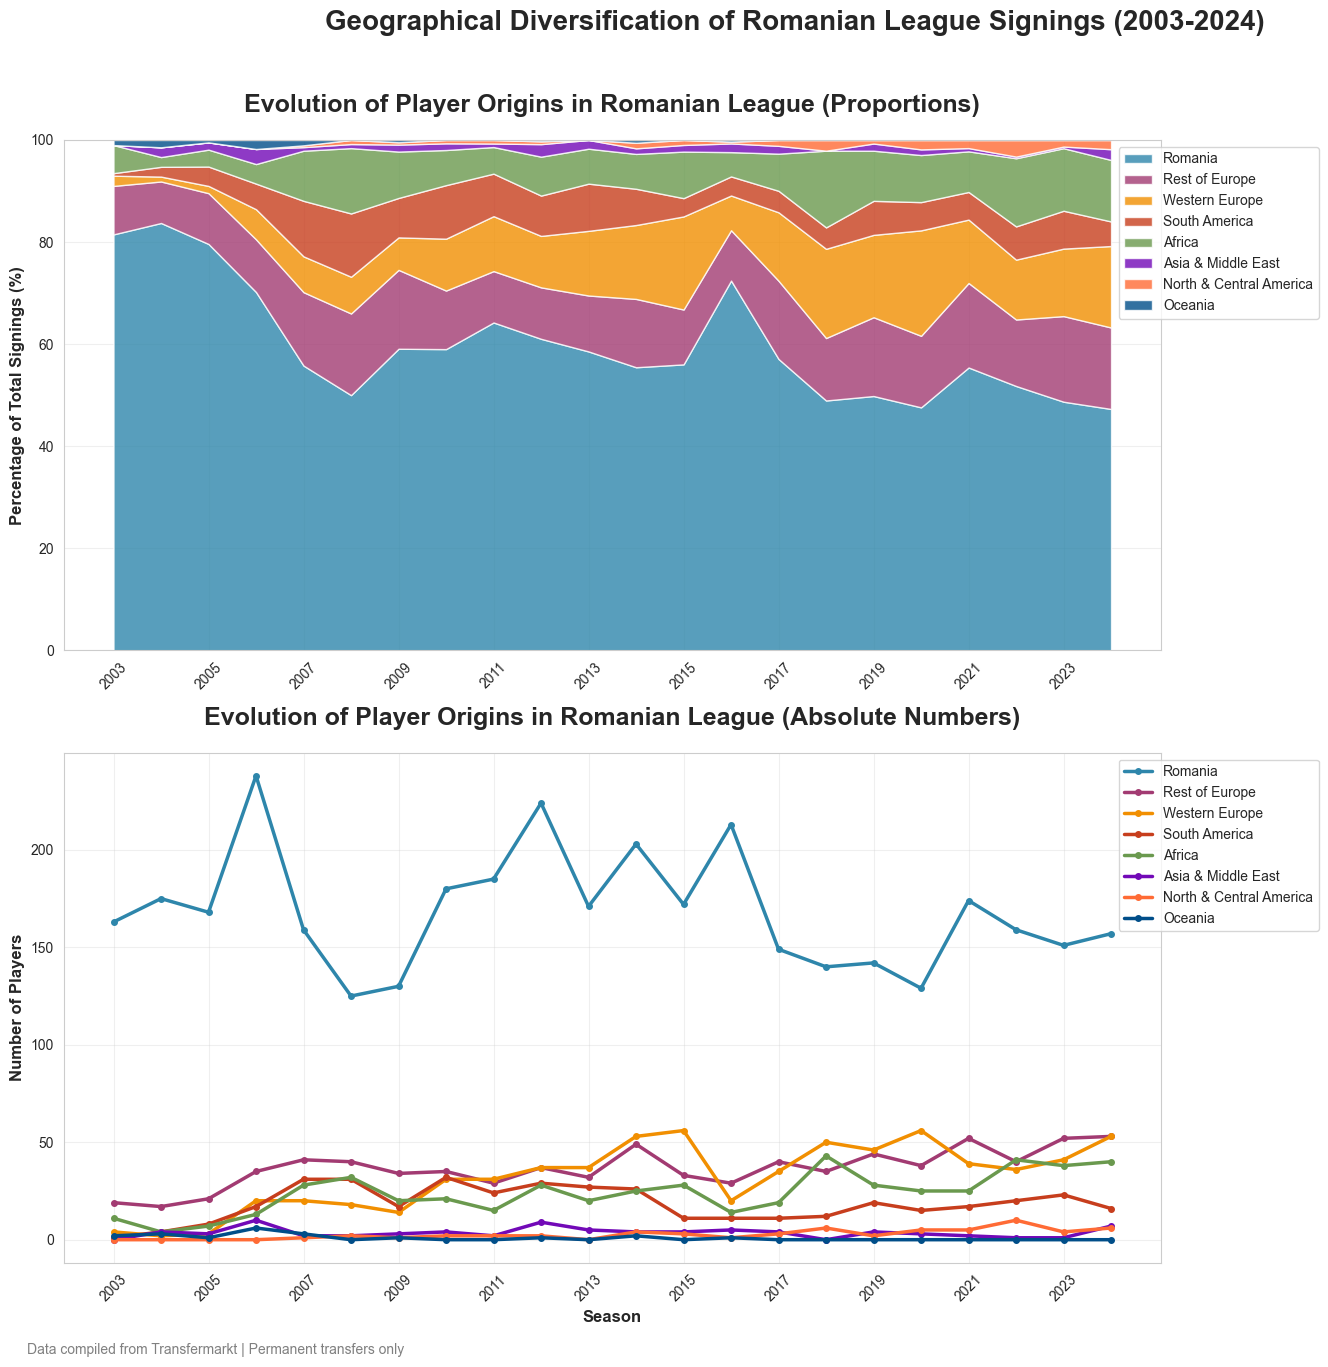

=== KEY INSIGHTS ===
Romanian players dominated in early years: 81.5% in 2003
Lowest Romanian proportion: 47.3% in 2024
Peak international diversification year: 2012 with 367 total signings
  - Romanian players: 224 (61.0%)
  - International players: 143 (39.0%)
  - Most represented foreign regions that year: {'Rest of Europe': 37, 'Western Europe': 37, 'South America': 29}
Most diverse region mix in recent years: 47.3% Romanian in 2024
  - Total signings in 2024: 332
  - International signings: 175 (52.7%)
  - Top 3 foreign regions in 2024: {'Rest of Europe': 53, 'Western Europe': 53, 'Africa': 40}

=== REGIONAL BREAKDOWN BY SEASON (8 regions) ===
player_region  Romania  Rest of Europe  Western Europe  South America  Africa  \
season                                                                          
2003               163              19               4              1      11   
2004               175              17               2              4       4   
2005               

In [28]:
# --- Data Preparation for Regional Analysis ---
# Define regional mapping for player nationalities
def map_nationality_to_region(nationality):
    """Maps player nationalities to broader geographical regions."""
    if pd.isna(nationality):
        return 'Unknown'
    
    # Eastern Europe (excluding Romania which gets its own category)
    eastern_europe = ['Bulgaria', 'Serbia', 'Croatia', 'Bosnia-Herzegovina', 
                     'Slovakia', 'Slovenia', 'Czech Republic', 'Poland', 'Hungary',
                     'North Macedonia', 'Montenegro', 'Albania', 'Ukraine', 'Moldova',
                     'Kosovo', 'Georgia', 'Belarus', 'Latvia', 'Lithuania', 'Estonia',
                     'Russia']
    
    # Western Europe
    western_europe = ['France', 'Spain', 'Netherlands', 'Italy', 'Belgium', 'Germany',
                     'Switzerland', 'Austria', 'Greece', 'Portugal', 'Sweden', 'Denmark',
                     'England', 'Scotland', 'Ireland', 'Finland', 'Iceland', 'Norway',
                     'Luxembourg', 'Faroe Islands']  # Moved Faroe Islands here as it's a Danish territory
    
    # South America
    south_america = ['Brazil', 'Argentina', 'Uruguay', 'Colombia', 'Chile', 'Paraguay',
                    'Venezuela', 'Bolivia', 'Peru', 'Suriname', 'Guyana', 'Ecuador']
    
    # Africa
    africa = ['Nigeria', 'Ghana', 'Cameroon', 'Ivory Coast', 'Senegal', 'Mali', 
             'DR Congo', 'Morocco', 'Algeria', 'Tunisia', 'Guinea', 'Cote d\'Ivoire',
             'Angola', 'Burkina Faso', 'Sierra Leone', 'Zimbabwe', 'Congo', 'Liberia',
             'Togo', 'Niger', 'Egypt', 'Gabon', 'Rwanda', 'Mozambique', 'Kenya',
             'Central African Republic', 'Zambia', 'Equatorial Guinea', 'Burundi',
             'Benin', 'Chad', 'Djibouti', 'South Africa', 'Sudan', 'Uganda', 'Libya',
             'Comoros', 'Mauritania', 'The Gambia', 'Madagascar', 'Malawi', 'Mauritius',
             'Guinea-Bissau', 'Cape Verde']  # Added missing African countries
    
    # Asia & Middle East
    asia_middle_east = ['Korea, South', 'Japan', 'Malaysia', 'Philippines', 'Hongkong',
                       'Cyprus', 'Armenia', 'Israel', 'Azerbaijan', 'Iraq', 'Jordan',
                       'Lebanon', 'Saudi Arabia', 'Syria', 'Palestine', 'Türkiye']  # Added Turkey
    
    # North & Central America
    north_central_america = ['United States', 'Canada', 'Costa Rica', 'Honduras',
                           'Guatemala', 'Dominican Republic', 'Haiti', 'El Salvador',
                           'Panama', 'Jamaica', 'Mexico', 'Curacao', 'Guadeloupe',
                           'Martinique', 'French Guiana']
    
    # Oceania
    oceania = ['Australia', 'New Zealand']
    
    if nationality == 'Romania':
        return 'Romania'
    elif nationality in eastern_europe:
        return 'Rest of Europe'
    elif nationality in western_europe:
        return 'Western Europe'
    elif nationality in south_america:
        return 'South America'
    elif nationality in africa:
        return 'Africa'
    elif nationality in asia_middle_east:
        return 'Asia & Middle East'
    elif nationality in north_central_america:
        return 'North & Central America'
    elif nationality in oceania:
        return 'Oceania'
    else:
        return 'Other'

# Apply regional mapping
df_permanent_arrivals['player_region'] = df_permanent_arrivals['player_nationality'].apply(map_nationality_to_region)

# Print nations that were attributed to "Other" region (should be minimal now)
other_nations = df_permanent_arrivals[df_permanent_arrivals['player_region'] == 'Other']['player_nationality'].unique()
print(f"Nations still attributed to 'Other' region: {', '.join(other_nations) if len(other_nations) > 0 else 'None'}")

# Count players by region and season
region_counts = df_permanent_arrivals.groupby(['season', 'player_region']).size().unstack(fill_value=0)

# Define expected regions in order of importance
expected_regions = ['Romania', 'Rest of Europe', 'Western Europe', 'South America', 
                   'Africa', 'Asia & Middle East', 'North & Central America', 'Oceania']

# Ensure all regions are present even if some seasons have 0
for region in expected_regions:
    if region not in region_counts.columns:
        region_counts[region] = 0

# Reorder columns for better visualization
available_regions = [region for region in expected_regions if region in region_counts.columns]
region_counts = region_counts[available_regions]

# --- Create the Visualization ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# Plot 1: Stacked Area Chart (Proportions)
region_proportions = region_counts.div(region_counts.sum(axis=1), axis=0) * 100

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#7209B7', '#FF6B35', '#004E89', '#B8860B'][:len(available_regions)]
ax1.stackplot(region_proportions.index, 
              *[region_proportions[region] for region in available_regions],
              labels=available_regions,
              colors=colors,
              alpha=0.8)

ax1.set_title('Evolution of Player Origins in Romanian League (Proportions)', 
              fontsize=18, fontweight='bold', pad=20)
ax1.set_ylabel('Percentage of Total Signings (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax1.grid(True, alpha=0.3)

# Plot 2: Line Chart (Absolute Numbers)
for i, region in enumerate(available_regions):
    ax2.plot(region_counts.index, region_counts[region], 
            marker='o', linewidth=2.5, markersize=4,
            color=colors[i], label=region)

ax2.set_title('Evolution of Player Origins in Romanian League (Absolute Numbers)', 
              fontsize=18, fontweight='bold', pad=20)
ax2.set_xlabel('Season', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Players', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax2.grid(True, alpha=0.3)

# Format x-axis for both plots
for ax in [ax1, ax2]:
    ax.set_xticks(range(2003, 2025, 2))
    ax.tick_params(axis='x', rotation=45)

# Add overall title and data source
fig.suptitle('Geographical Diversification of Romanian League Signings (2003-2024)', 
             fontsize=20, fontweight='bold', y=0.98)
fig.text(0.02, 0.02, 'Data compiled from Transfermarkt | Permanent transfers only', 
         fontsize=10, color='gray')

plt.tight_layout(rect=[0, 0.03, 0.85, 0.96])
plt.show()

# Print some key insights with detailed explanations
print("=== KEY INSIGHTS ===")
print(f"Romanian players dominated in early years: {region_proportions.loc[2003, 'Romania']:.1f}% in 2003")
print(f"Lowest Romanian proportion: {region_proportions['Romania'].min():.1f}% in {region_proportions['Romania'].idxmin()}")

# Peak diversification analysis
total_signings_per_year = region_counts.sum(axis=1)
peak_year = total_signings_per_year.idxmax()
peak_signings = total_signings_per_year.max()
peak_year_breakdown = region_counts.loc[peak_year]
non_romanian_regions = peak_year_breakdown.drop('Romania').sum()

print(f"Peak international diversification year: {peak_year} with {peak_signings} total signings")
print(f"  - Romanian players: {peak_year_breakdown['Romania']} ({peak_year_breakdown['Romania']/peak_signings*100:.1f}%)")
print(f"  - International players: {non_romanian_regions} ({non_romanian_regions/peak_signings*100:.1f}%)")
print(f"  - Most represented foreign regions that year: {peak_year_breakdown.drop('Romania').nlargest(3).to_dict()}")

# Recent diversification analysis
recent_year = 2024
recent_breakdown = region_counts.loc[recent_year]
recent_total = recent_breakdown.sum()
recent_non_romanian = recent_breakdown.drop('Romania').sum()

print(f"Most diverse region mix in recent years: {region_proportions.loc[recent_year, 'Romania']:.1f}% Romanian in {recent_year}")
print(f"  - Total signings in {recent_year}: {recent_total}")
print(f"  - International signings: {recent_non_romanian} ({recent_non_romanian/recent_total*100:.1f}%)")
print(f"  - Top 3 foreign regions in {recent_year}: {recent_breakdown.drop('Romania').nlargest(3).to_dict()}")

# Show the data table for reference
print(f"\n=== REGIONAL BREAKDOWN BY SEASON ({len(available_regions)} regions) ===")
print(region_counts.round(0))

## Viz 5: Age Distribution of Paid vs. Free Transfers

In [29]:
# --- Clean age data for analysis ---
# Convert player_age to numeric, handling any invalid values
df_permanent_arrivals['player_age_numeric'] = pd.to_numeric(df_permanent_arrivals['player_age'], errors='coerce')

# Create a clean dataset for age analysis (excluding records with invalid ages)
df_age_analysis = df_permanent_arrivals.dropna(subset=['player_age_numeric']).copy()
df_age_analysis['player_age'] = df_age_analysis['player_age_numeric']  # Use clean numeric version

print(f"Records available for age analysis: {len(df_age_analysis):,} (excluded {df_permanent_arrivals['player_age_numeric'].isna().sum()} records with invalid ages)")
print(f"Age range: {df_age_analysis['player_age'].min():.0f} to {df_age_analysis['player_age'].max():.0f} years")

Records available for age analysis: 6,300 (excluded 3 records with invalid ages)
Age range: 13 to 40 years


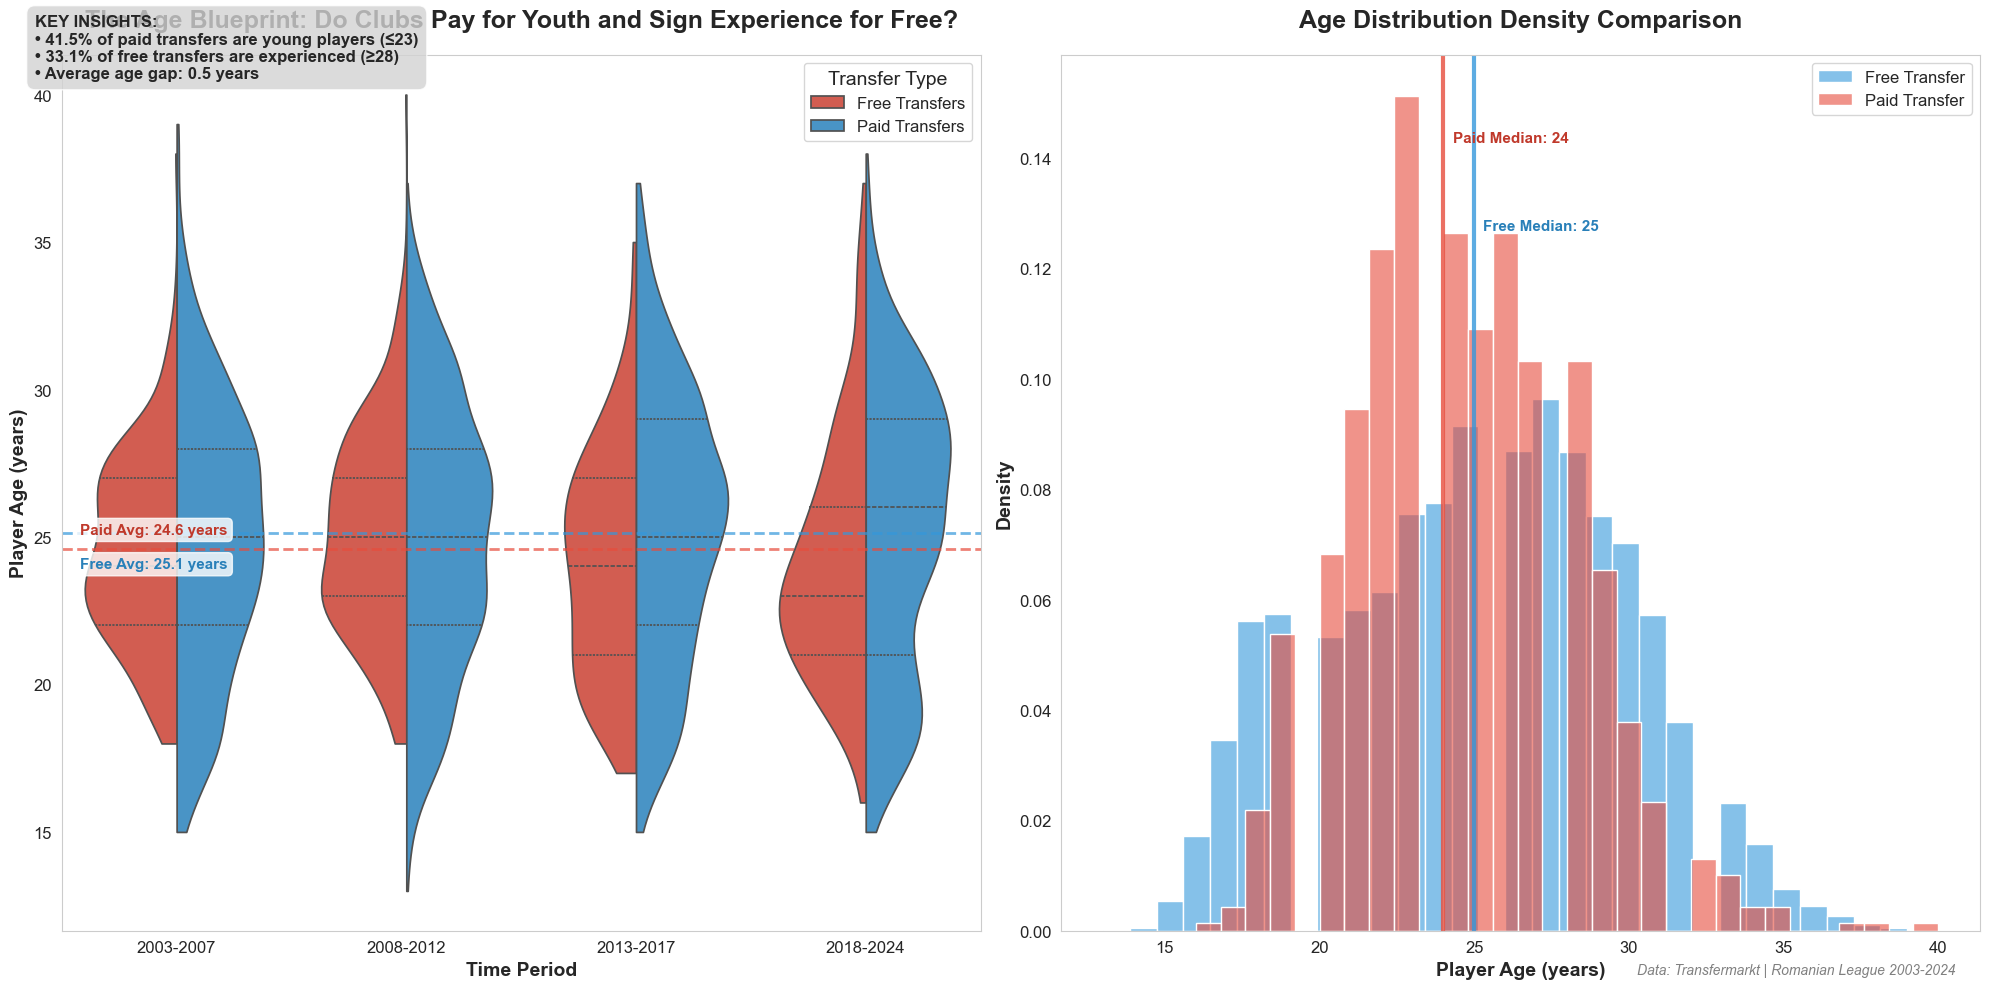

=== DETAILED AGE STRATEGY ANALYSIS ===

PAID TRANSFERS (n=860):
  Average age: 24.6 years
  Median age: 24 years
  Young players (18-23): 357 (41.5%)
  High-value young signings (≤23, ≥€500k): 99

FREE TRANSFERS (n=5,440):
  Average age: 25.1 years
  Median age: 25 years
  Experienced players (28+): 1,802 (33.1%)

AGE BRACKET BREAKDOWN:
  18-22: 249 paid (15.6%), 1,350 free (84.4%)
  23-27: 424 paid (17.4%), 2,016 free (82.6%)
  28-32: 167 paid (9.8%), 1,542 free (90.2%)
  33+: 16 paid (5.8%), 260 free (94.2%)


In [30]:
# Create season brackets for a cleaner analysis
bins = [2003, 2008, 2013, 2018, 2024]  # More meaningful periods
labels = ['2003-2007', '2008-2012', '2013-2017', '2018-2024']
df_age_analysis['season_bracket'] = pd.cut(df_age_analysis['season'], bins=bins, labels=labels, right=False)

# Calculate key statistics for annotations
paid_avg_age = df_age_analysis[df_age_analysis['transfer_category'] == 'Paid Transfer']['player_age'].mean()
free_avg_age = df_age_analysis[df_age_analysis['transfer_category'] == 'Free Transfer']['player_age'].mean()

# Create the enhanced visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Main violin plot
sns.violinplot(
    data=df_age_analysis.dropna(subset=['season_bracket', 'player_age']),
    x='season_bracket',
    y='player_age',
    hue='transfer_category',
    split=True,
    inner='quart',
    palette={'Free Transfer': '#3498db', 'Paid Transfer': '#e74c3c'},
    ax=ax1,
    cut=0  # Don't extend beyond data range
)

ax1.set_title('The Age Blueprint: Do Clubs Pay for Youth and Sign Experience for Free?', 
              fontsize=18, fontweight='bold', pad=20)
ax1.set_xlabel('Time Period', fontsize=14, fontweight='bold')
ax1.set_ylabel('Player Age (years)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=12)

# Add horizontal lines for average ages
ax1.axhline(paid_avg_age, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=2)
ax1.axhline(free_avg_age, color='#3498db', linestyle='--', alpha=0.7, linewidth=2)

# Add average age annotations
ax1.text(0.02, paid_avg_age + 0.5, f'Paid Avg: {paid_avg_age:.1f} years', 
         transform=ax1.get_yaxis_transform(), fontsize=11, color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax1.text(0.02, free_avg_age - 1.2, f'Free Avg: {free_avg_age:.1f} years', 
         transform=ax1.get_yaxis_transform(), fontsize=11, color='#2980b9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Improve legend for main plot
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Free Transfers', 'Paid Transfers'], 
           title='Transfer Type', fontsize=12, title_fontsize=14, loc='upper right')

# Secondary plot: Age distribution comparison
age_data = []
for category in ['Free Transfer', 'Paid Transfer']:
    ages = df_age_analysis[df_age_analysis['transfer_category'] == category]['player_age']
    age_data.extend([(age, category) for age in ages])

age_df = pd.DataFrame(age_data, columns=['age', 'category'])

# Create overlapping density plots
for category, color in [('Free Transfer', '#3498db'), ('Paid Transfer', '#e74c3c')]:
    data = age_df[age_df['category'] == category]['age']
    sns.histplot(data=data, bins=30, alpha=0.6, color=color, 
                stat='density', ax=ax2, label=category)

ax2.set_title('Age Distribution Density Comparison', fontsize=18, fontweight='bold', pad=20)
ax2.set_xlabel('Player Age (years)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Density', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

# Add vertical lines for medians
paid_median = df_age_analysis[df_age_analysis['transfer_category'] == 'Paid Transfer']['player_age'].median()
free_median = df_age_analysis[df_age_analysis['transfer_category'] == 'Free Transfer']['player_age'].median()

ax2.axvline(paid_median, color='#e74c3c', linestyle='-', alpha=0.8, linewidth=3)
ax2.axvline(free_median, color='#3498db', linestyle='-', alpha=0.8, linewidth=3)

# Add median annotations
ax2.text(paid_median + 0.3, ax2.get_ylim()[1] * 0.9, f'Paid Median: {paid_median:.0f}', 
         rotation=0, fontsize=11, color='#c0392b', fontweight='bold')
ax2.text(free_median + 0.3, ax2.get_ylim()[1] * 0.8, f'Free Median: {free_median:.0f}', 
         rotation=0, fontsize=11, color='#2980b9', fontweight='bold')

# Calculate and display key insights
young_paid = len(df_age_analysis[(df_age_analysis['transfer_category'] == 'Paid Transfer') & 
                                      (df_age_analysis['player_age'] <= 23)])
total_paid = len(df_age_analysis[df_age_analysis['transfer_category'] == 'Paid Transfer'])
young_paid_pct = (young_paid / total_paid) * 100

experienced_free = len(df_age_analysis[(df_age_analysis['transfer_category'] == 'Free Transfer') & 
                                            (df_age_analysis['player_age'] >= 28)])
total_free = len(df_age_analysis[df_age_analysis['transfer_category'] == 'Free Transfer'])
experienced_free_pct = (experienced_free / total_free) * 100

# Add insight box
insight_text = (f"KEY INSIGHTS:\n"
               f"• {young_paid_pct:.1f}% of paid transfers are young players (≤23)\n"
               f"• {experienced_free_pct:.1f}% of free transfers are experienced (≥28)\n"
               f"• Average age gap: {abs(paid_avg_age - free_avg_age):.1f} years")

fig.text(0.02, 0.98, insight_text, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8),
         fontweight='bold')

# Add data source
fig.text(0.98, 0.02, 'Data: Transfermarkt | Romanian League 2003-2024', 
         ha='right', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

# Print detailed statistical analysis
print("=== DETAILED AGE STRATEGY ANALYSIS ===")
print(f"\nPAID TRANSFERS (n={total_paid:,}):")
print(f"  Average age: {paid_avg_age:.1f} years")
print(f"  Median age: {paid_median:.0f} years")
print(f"  Young players (18-23): {young_paid:,} ({young_paid_pct:.1f}%)")

young_expensive = df_age_analysis[
    (df_age_analysis['transfer_category'] == 'Paid Transfer') & 
    (df_age_analysis['player_age'] <= 23) & 
    (df_age_analysis['transfer_fee'] >= 500000)
]
print(f"  High-value young signings (≤23, ≥€500k): {len(young_expensive):,}")

print(f"\nFREE TRANSFERS (n={total_free:,}):")
print(f"  Average age: {free_avg_age:.1f} years")
print(f"  Median age: {free_median:.0f} years")
print(f"  Experienced players (28+): {experienced_free:,} ({experienced_free_pct:.1f}%)")

# Age bracket analysis
print(f"\nAGE BRACKET BREAKDOWN:")
for bracket in ['18-22', '23-27', '28-32', '33+']:
    if bracket == '18-22':
        condition = (df_age_analysis['player_age'] >= 18) & (df_age_analysis['player_age'] <= 22)
    elif bracket == '23-27':
        condition = (df_age_analysis['player_age'] >= 23) & (df_age_analysis['player_age'] <= 27)
    elif bracket == '28-32':
        condition = (df_age_analysis['player_age'] >= 28) & (df_age_analysis['player_age'] <= 32)
    else:
        condition = df_age_analysis['player_age'] >= 33
    
    bracket_data = df_age_analysis[condition]
    paid_count = len(bracket_data[bracket_data['transfer_category'] == 'Paid Transfer'])
    free_count = len(bracket_data[bracket_data['transfer_category'] == 'Free Transfer'])
    total_bracket = paid_count + free_count
    
    if total_bracket > 0:
        paid_pct = (paid_count / total_bracket) * 100
        print(f"  {bracket}: {paid_count:,} paid ({paid_pct:.1f}%), {free_count:,} free ({100-paid_pct:.1f}%)")

## Viz 6: Transfer Corridors & Scouting Networks - Complete Analysis

=== ANALYZING TRANSFER CORRIDORS & SCOUTING NETWORKS ===
Total foreign transfers: 2,254
From 102 different countries


C:\Users\stoic\AppData\Local\Temp\ipykernel_5188\218302419.py:192: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax6.boxplot(age_by_region, labels=regions_for_plot, patch_artist=True)


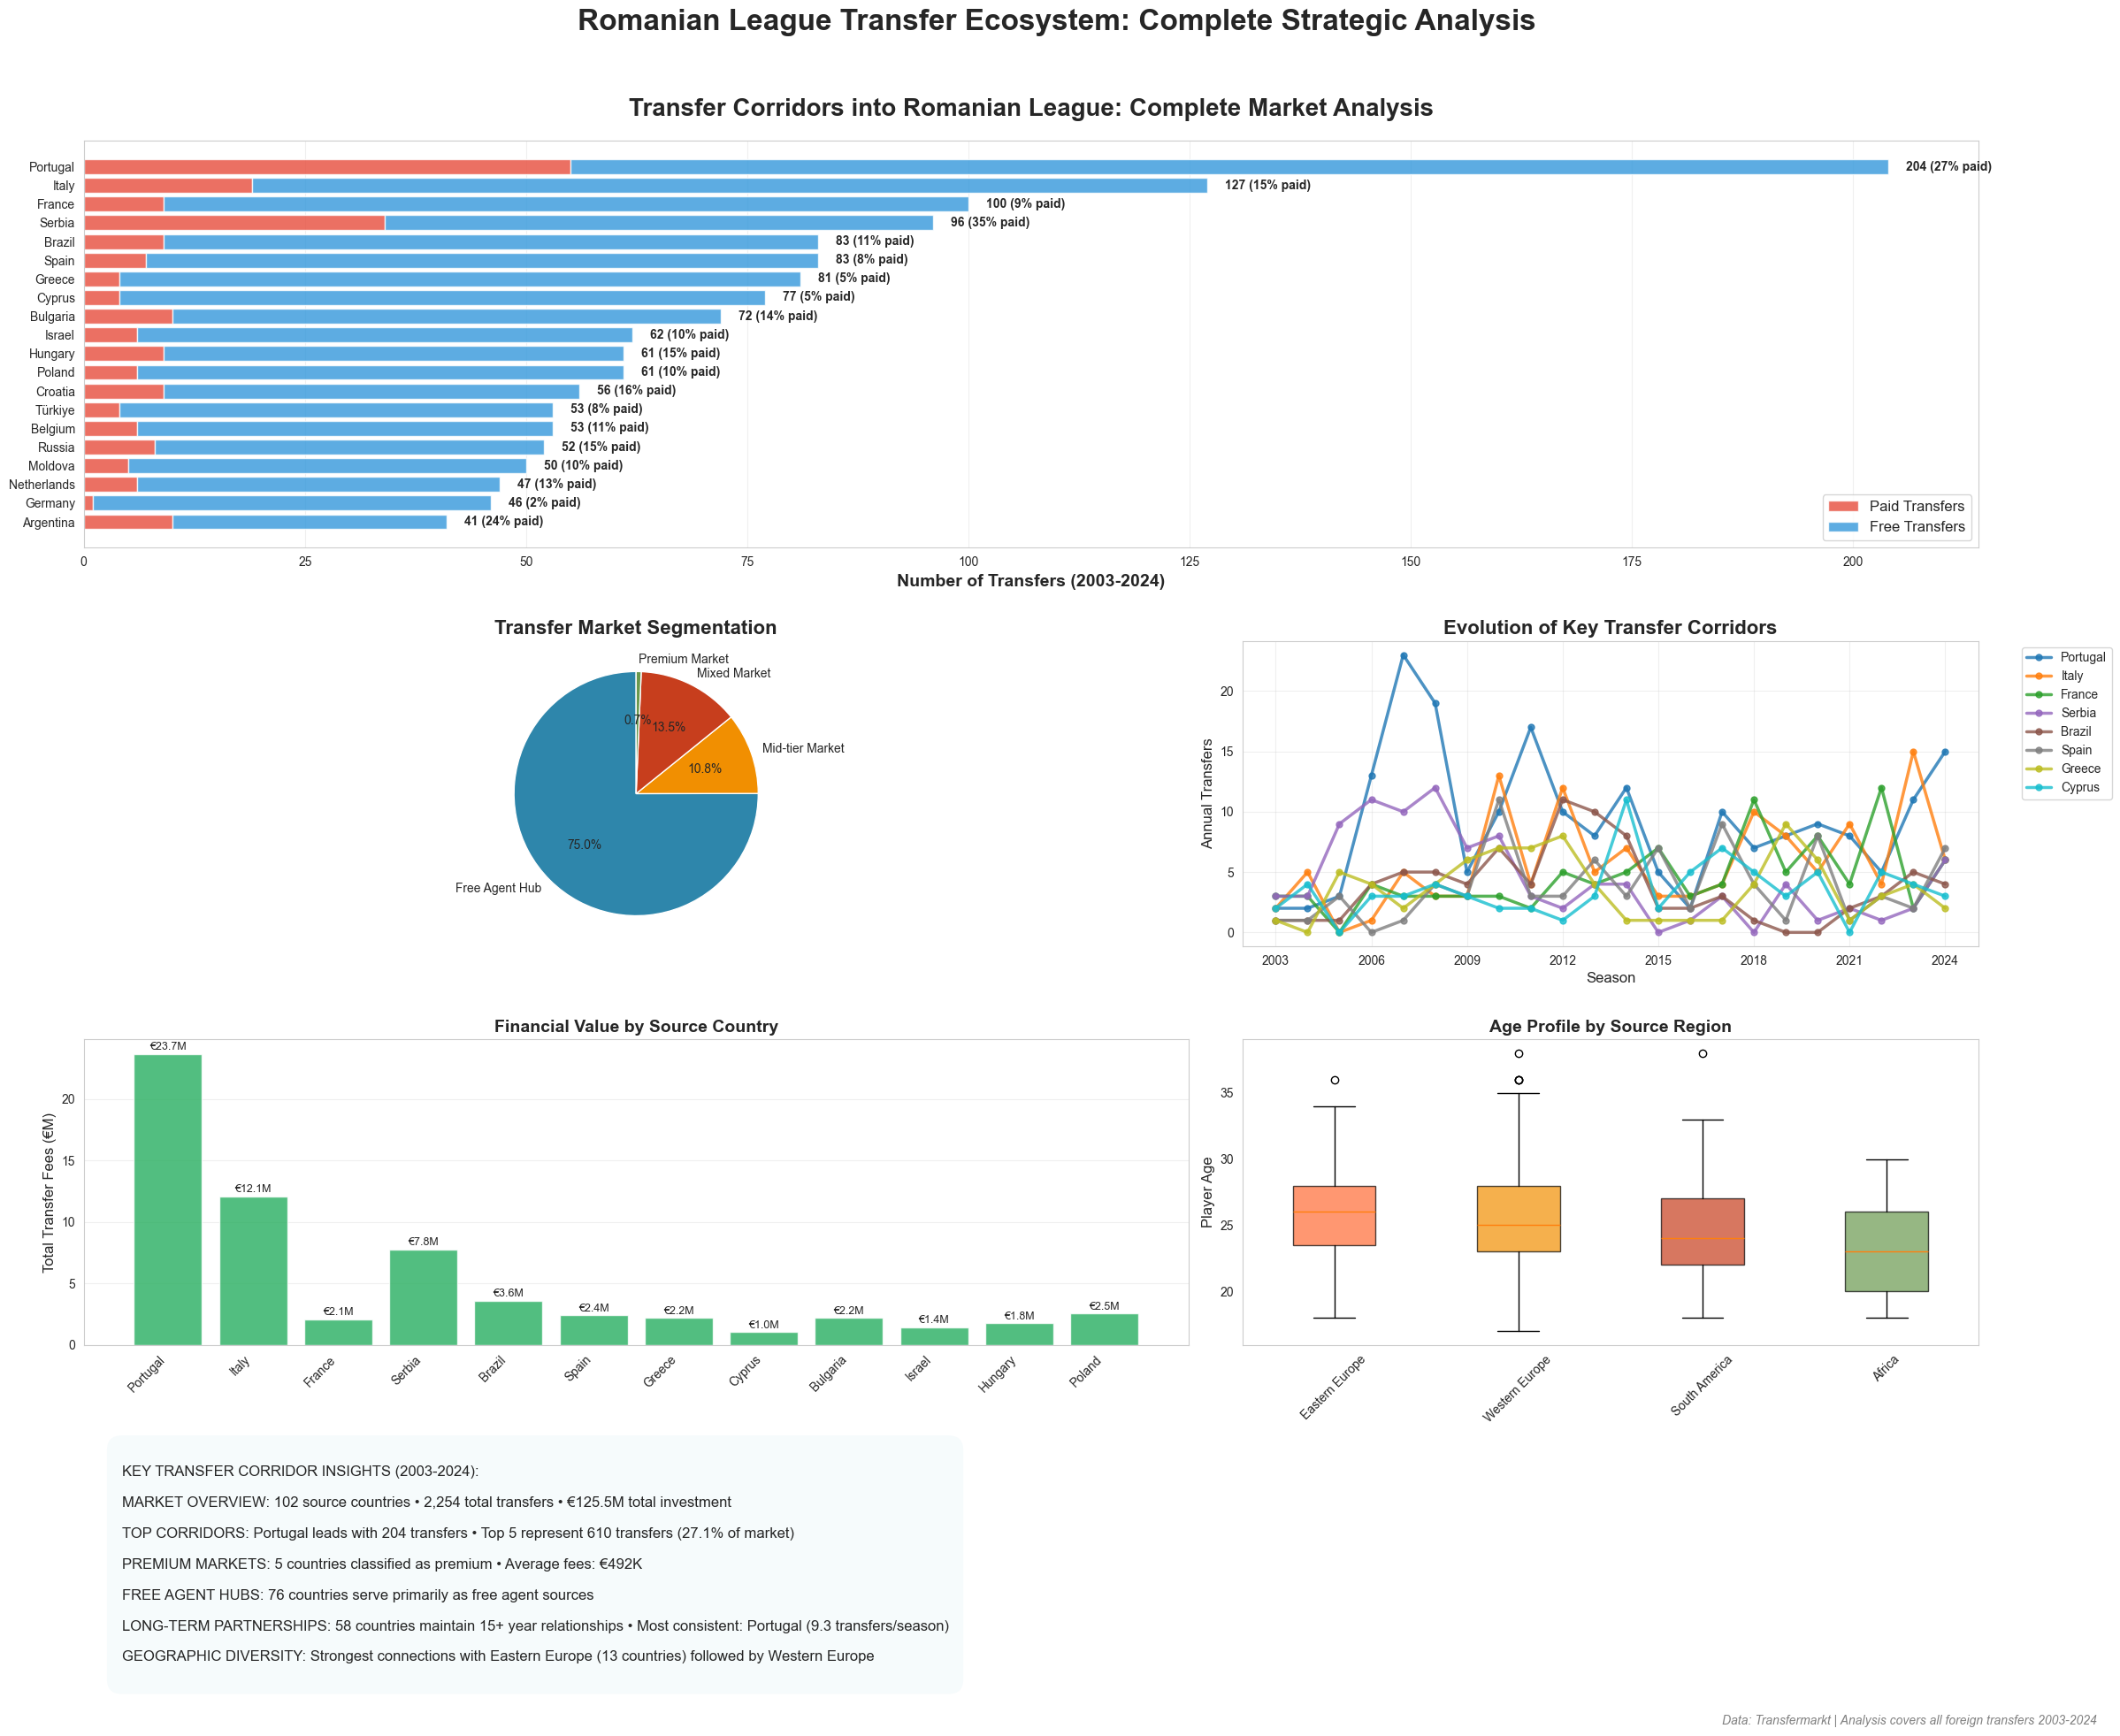


=== TOP 15 TRANSFER CORRIDORS - DETAILED ANALYSIS ===
 country  total_transfers  paid_transfers  free_transfers  paid_percentage  avg_fee  relationship_duration  market_segment
Portugal              204              55             149               27   430364                     22    Mixed Market
   Italy              127              19             108               15   636579                     22  Free Agent Hub
  France              100               9              91                9   232222                     22  Free Agent Hub
  Serbia               96              34              62               35   228824                     22 Mid-tier Market
  Brazil               83               9              74               11   397778                     22  Free Agent Hub
   Spain               83               7              76                8   342857                     22  Free Agent Hub
  Greece               81               4              77                5   550000 

In [32]:
# === COMPREHENSIVE TRANSFER CORRIDORS ANALYSIS ===
print("=== ANALYZING TRANSFER CORRIDORS & SCOUTING NETWORKS ===")

# Focus on transfers from outside Romania (club country, not player nationality)
foreign_arrivals = df_permanent_arrivals[
    (df_permanent_arrivals['country_2'].notna()) &
    (df_permanent_arrivals['country_2'] != 'Romania')
].copy()

print(f"Total foreign transfers: {len(foreign_arrivals):,}")
print(f"From {foreign_arrivals['country_2'].nunique()} different countries")

# --- 1. COMPREHENSIVE COUNTRY ANALYSIS ---
country_stats = []
for country in foreign_arrivals['country_2'].unique():
    country_data = foreign_arrivals[foreign_arrivals['country_2'] == country]
    
    # Basic stats
    total_transfers = len(country_data)
    paid_transfers = len(country_data[country_data['transfer_category'] == 'Paid Transfer'])
    free_transfers = len(country_data[country_data['transfer_category'] == 'Free Transfer'])
    
    # Financial stats (for paid transfers)
    paid_data = country_data[country_data['transfer_category'] == 'Paid Transfer']
    total_fees = paid_data['transfer_fee'].sum()
    avg_fee = paid_data['transfer_fee'].mean() if len(paid_data) > 0 else 0
    
    # Time period analysis
    seasons = country_data['season'].unique()
    first_season = seasons.min()
    last_season = seasons.max()
    active_seasons = len(seasons)
    
    # Player age analysis
    avg_age = country_data['player_age_numeric'].mean()
    
    country_stats.append({
        'country': country,
        'total_transfers': total_transfers,
        'paid_transfers': paid_transfers,
        'free_transfers': free_transfers,
        'paid_percentage': (paid_transfers / total_transfers) * 100 if total_transfers > 0 else 0,
        'total_fees': total_fees,
        'avg_fee': avg_fee,
        'first_season': first_season,
        'last_season': last_season,
        'active_seasons': active_seasons,
        'avg_age': avg_age,
        'relationship_duration': last_season - first_season + 1,
        'transfers_per_season': total_transfers / active_seasons if active_seasons > 0 else 0
    })

country_analysis_df = pd.DataFrame(country_stats).sort_values('total_transfers', ascending=False)

# --- 2. TEMPORAL EVOLUTION ANALYSIS ---
# Track top countries over time
yearly_country_flows = foreign_arrivals.groupby(['season', 'country_2']).size().unstack(fill_value=0)

# Get top 15 countries for detailed time series analysis
top_countries = country_analysis_df.head(15)['country'].tolist()

#
# Classify countries by transfer patterns
def classify_transfer_market(row):
    """Classify countries by their transfer characteristics"""
    if row['avg_fee'] >= 200000 and row['paid_percentage'] >= 50:
        return 'Premium Market'
    elif row['avg_fee'] >= 100000 and row['paid_percentage'] >= 30:
        return 'Mid-tier Market'
    elif row['paid_percentage'] >= 20:
        return 'Mixed Market'
    else:
        return 'Free Agent Hub'

country_analysis_df['market_segment'] = country_analysis_df.apply(classify_transfer_market, axis=1)

# --- CREATE THE COMPREHENSIVE VISUALIZATION ---
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(4, 2, height_ratios=[2, 1.5, 1.5, 1.2], width_ratios=[1.5, 1])

# --- PLOT 1: COMPREHENSIVE TRANSFER FLOWS (Top 20) ---
ax1 = fig.add_subplot(gs[0, :])
top_20 = country_analysis_df.head(20)

# Create stacked horizontal bar chart
paid_bars = ax1.barh(range(len(top_20)), top_20['paid_transfers'], 
                     color='#e74c3c', alpha=0.8, label='Paid Transfers')
free_bars = ax1.barh(range(len(top_20)), top_20['free_transfers'], 
                     left=top_20['paid_transfers'], color='#3498db', alpha=0.8, label='Free Transfers')

ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['country'])
ax1.set_xlabel('Number of Transfers (2003-2024)', fontsize=14, fontweight='bold')
ax1.set_title('Transfer Corridors into Romanian League: Complete Market Analysis', 
              fontsize=20, fontweight='bold', pad=20)

# Add percentage labels
for i, (idx, row) in enumerate(top_20.iterrows()):
    total = row['total_transfers']
    paid_pct = (row['paid_transfers'] / total) * 100
    ax1.text(total + 2, i, f"{total} ({paid_pct:.0f}% paid)", 
             va='center', fontsize=10, fontweight='bold')

ax1.legend(loc='lower right', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()  # Make it descending order

# --- PLOT 2: MARKET SEGMENTATION ---
ax2 = fig.add_subplot(gs[1, 0])
segment_data = country_analysis_df.groupby('market_segment').agg({
    'total_transfers': 'sum',
    'country': 'count'
}).reset_index()

colors_segment = ['#2E86AB', '#F18F01', '#C73E1D', '#6A994E']
wedges, texts, autotexts = ax2.pie(segment_data['total_transfers'], 
                                   labels=segment_data['market_segment'],
                                   autopct='%1.1f%%',
                                   colors=colors_segment,
                                   startangle=90)
ax2.set_title('Transfer Market Segmentation', fontsize=16, fontweight='bold')

# --- PLOT 3: EVOLUTION OF TOP CORRIDORS ---
ax3 = fig.add_subplot(gs[1, 1:])
top_8_countries = top_countries[:8]
colors_time = plt.cm.tab10(np.linspace(0, 1, len(top_8_countries)))

for i, country in enumerate(top_8_countries):
    if country in yearly_country_flows.columns:
        y_values = yearly_country_flows[country].values
        ax3.plot(yearly_country_flows.index, y_values, 
                marker='o', linewidth=2.5, markersize=5, 
                color=colors_time[i], label=country, alpha=0.8)

ax3.set_title('Evolution of Key Transfer Corridors', fontsize=16, fontweight='bold')
ax3.set_xlabel('Season', fontsize=12)
ax3.set_ylabel('Annual Transfers', fontsize=12)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(2003, 2025, 3))

# --- PLOT 4: FINANCIAL VALUE BY CORRIDOR ---
ax4 = fig.add_subplot(gs[2, 0])
top_financial = country_analysis_df[country_analysis_df['total_fees'] > 0].head(12)
bars = ax4.bar(range(len(top_financial)), top_financial['total_fees'] / 1000000, 
               color='#27AE60', alpha=0.8)
ax4.set_xticks(range(len(top_financial)))
ax4.set_xticklabels(top_financial['country'], rotation=45, ha='right')
ax4.set_ylabel('Total Transfer Fees (€M)', fontsize=12)
ax4.set_title('Financial Value by Source Country', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'€{height:.1f}M', ha='center', va='bottom', fontsize=9)

# --- PLOT 6: AGE PROFILE BY SOURCE REGION ---
ax6 = fig.add_subplot(gs[2, 1])

# Group countries by region for age analysis
region_mapping = {
    'Eastern Europe': ['Serbia', 'Croatia', 'Bulgaria', 'Bosnia-Herzegovina', 'Ukraine', 'Moldova', 'Poland', 'Czech Republic', 'Slovakia', 'Slovenia', 'Hungary', 'North Macedonia', 'Montenegro'],
    'Western Europe': ['France', 'Italy', 'Spain', 'Germany', 'Netherlands', 'Portugal', 'Belgium', 'Switzerland', 'Austria', 'England', 'Greece'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Uruguay', 'Chile', 'Paraguay', 'Venezuela'],
    'Africa': ['Nigeria', 'Ghana', 'Cameroon', 'Morocco', 'Algeria', 'Tunisia', 'Senegal'],
    'Other': []
}

def map_to_region(country):
    for region, countries in region_mapping.items():
        if country in countries:
            return region
    return 'Other'

foreign_arrivals['source_region'] = foreign_arrivals['country_2'].apply(map_to_region)
age_by_region = []
regions_for_plot = []

for region in ['Eastern Europe', 'Western Europe', 'South America', 'Africa']:
    region_data = foreign_arrivals[
        (foreign_arrivals['source_region'] == region) & 
        (foreign_arrivals['player_age_numeric'].notna())
    ]['player_age_numeric']
    if len(region_data) > 10:  # Only include regions with sufficient data
        age_by_region.append(region_data)
        regions_for_plot.append(region)

if age_by_region:
    box_plot = ax6.boxplot(age_by_region, labels=regions_for_plot, patch_artist=True)
    colors_box = ['#FF6B35', '#F18F01', '#C73E1D', '#6A994E']
    for patch, color in zip(box_plot['boxes'], colors_box[:len(box_plot['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

ax6.set_ylabel('Player Age', fontsize=12)
ax6.set_title('Age Profile by Source Region', fontsize=14, fontweight='bold')
ax6.tick_params(axis='x', rotation=45)

# --- PLOT 7: COMPREHENSIVE INSIGHTS TABLE ---
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')

# Create insights text
insights_text = f"""
KEY TRANSFER CORRIDOR INSIGHTS (2003-2024):

MARKET OVERVIEW: {len(country_analysis_df)} source countries • {len(foreign_arrivals):,} total transfers • €{country_analysis_df['total_fees'].sum()/1000000:.1f}M total investment

TOP CORRIDORS: {top_20.iloc[0]['country']} leads with {top_20.iloc[0]['total_transfers']} transfers • Top 5 represent {top_20.head(5)['total_transfers'].sum()} transfers ({top_20.head(5)['total_transfers'].sum()/len(foreign_arrivals)*100:.1f}% of market)

PREMIUM MARKETS: {len(country_analysis_df[country_analysis_df['market_segment'] == 'Premium Market'])} countries classified as premium • Average fees: €{country_analysis_df[country_analysis_df['market_segment'] == 'Premium Market']['avg_fee'].mean()/1000:.0f}K

FREE AGENT HUBS: {len(country_analysis_df[country_analysis_df['market_segment'] == 'Free Agent Hub'])} countries serve primarily as free agent sources

LONG-TERM PARTNERSHIPS: {len(country_analysis_df[country_analysis_df['relationship_duration'] >= 15])} countries maintain 15+ year relationships • Most consistent: {country_analysis_df.loc[country_analysis_df['transfers_per_season'].idxmax(), 'country']} ({country_analysis_df['transfers_per_season'].max():.1f} transfers/season)

GEOGRAPHIC DIVERSITY: Strongest connections with Eastern Europe ({foreign_arrivals[foreign_arrivals['source_region'] == 'Eastern Europe']['country_2'].nunique()} countries) followed by Western Europe
"""

ax7.text(0.02, 0.95, insights_text, fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=1', facecolor='lightblue', alpha=0.1))

plt.suptitle('Romanian League Transfer Ecosystem: Complete Strategic Analysis', 
             fontsize=24, fontweight='bold', y=0.98)

plt.figtext(0.99, 0.01, 'Data: Transfermarkt | Analysis covers all foreign transfers 2003-2024', 
            ha='right', fontsize=10, color='gray', style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

# Print detailed country analysis
print(f"\n=== TOP 15 TRANSFER CORRIDORS - DETAILED ANALYSIS ===")
display_cols = ['country', 'total_transfers', 'paid_transfers', 'free_transfers', 
               'paid_percentage', 'avg_fee', 'relationship_duration', 'market_segment']
print(country_analysis_df[display_cols].head(15).to_string(index=False, float_format='%.0f'))

print(f"\n=== MARKET SEGMENTATION BREAKDOWN ===")
segment_summary = country_analysis_df.groupby('market_segment').agg({
    'country': 'count',
    'total_transfers': 'sum',
    'avg_fee': 'mean',
    'paid_percentage': 'mean'
}).round(0)
print(segment_summary)